In [1]:
import pandas as pd
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

nav_path = "/content/drive/MyDrive/Bluestock /capstone/cleaned/nav_history_cleaned.csv"

nav_df = pd.read_csv(nav_path)

print("Shape:", nav_df.shape)
print(nav_df.head())
print(nav_df.columns.tolist())

Shape: (45962, 3)
   amfi_code        date       nav
0     100016  2022-01-02  512.1124
1     100016  2022-01-03  503.1674
2     100016  2022-01-04  531.2850
3     100016  2022-01-06  474.1732
4     100016  2022-01-07  452.5840
['amfi_code', 'date', 'nav']


In [5]:
# Make sure dates and NAV values are in the correct format
nav_df["date"] = pd.to_datetime(nav_df["date"])
nav_df["nav"] = pd.to_numeric(nav_df["nav"], errors="coerce")

# Sort each scheme by date
nav_df = nav_df.sort_values(["amfi_code", "date"])

# Calculate daily return for each scheme
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"].pct_change()
)

print(nav_df[["amfi_code", "date", "nav", "daily_return"]].head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-02  512.1124           NaN
1     100016 2022-01-03  503.1674     -0.017467
2     100016 2022-01-04  531.2850      0.055881
3     100016 2022-01-06  474.1732     -0.107497
4     100016 2022-01-07  452.5840     -0.045530
5     100016 2022-01-08  433.0211     -0.043225
6     100016 2022-01-09  424.3603     -0.020001
7     100016 2022-01-11  448.4277      0.056715
8     100016 2022-01-12  482.4201      0.075804
9     100016 2022-02-02  515.5386      0.068651


#Historical VaR (95%) and CVaR

In [6]:
# Calculate 95% Historical VaR and CVaR for each scheme
results = []

for code, group in nav_df.groupby("amfi_code"):
    returns = group["daily_return"].dropna()

    if returns.empty:
        continue

    # 5th percentile of daily returns
    var_95 = returns.quantile(0.05)

    # Mean of returns at or below the VaR threshold
    cvar_95 = returns[returns <= var_95].mean()

    results.append({
        "amfi_code": code,
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

var_cvar_df = pd.DataFrame(results)

print("Schemes calculated:", len(var_cvar_df))
display(var_cvar_df.head())

Schemes calculated: 40


,amfi_code,VaR_95,CVaR_95
0,100016,-0.064206,-0.105590
1,100025,-0.020707,-0.042778
2,100033,-0.069870,-0.174555
3,101206,-0.074686,-0.151855
4,101207,-0.089537,-0.161950


In [7]:
# Save the VaR and CVaR report
var_cvar_df.to_csv("var_cvar_report.csv", index=False)

print("Report saved:", "var_cvar_report.csv")

Report saved: var_cvar_report.csv


#Rolling 90-day Sharpe

In [8]:
# Calculate rolling 90-day Sharpe for the 5 key funds

import matplotlib.pyplot as plt

key_funds = {
    119551: "SBI Bluechip",
    120503: "ICICI Bluechip",
    118632: "Nippon Large Cap",
    119092: "Axis Bluechip",
    120841: "Kotak Bluechip"
}

rolling_sharpe = {}

for code, fund_name in key_funds.items():
    fund_data = (
        nav_df[nav_df["amfi_code"] == code]
        .sort_values("date")
        .copy()
    )

    returns = fund_data["daily_return"]

    rolling_mean = returns.rolling(window=90).mean()
    rolling_std = returns.rolling(window=90).std()

    fund_data["rolling_sharpe"] = (
        rolling_mean / rolling_std
    ) * np.sqrt(252)

    rolling_sharpe[fund_name] = fund_data[
        ["date", "rolling_sharpe"]
    ]

    print(f"{fund_name}: {fund_data['rolling_sharpe'].notna().sum()} rolling values")

SBI Bluechip: 1058 rolling values
ICICI Bluechip: 1060 rolling values
Nippon Large Cap: 1060 rolling values
Axis Bluechip: 1055 rolling values
Kotak Bluechip: 1060 rolling values


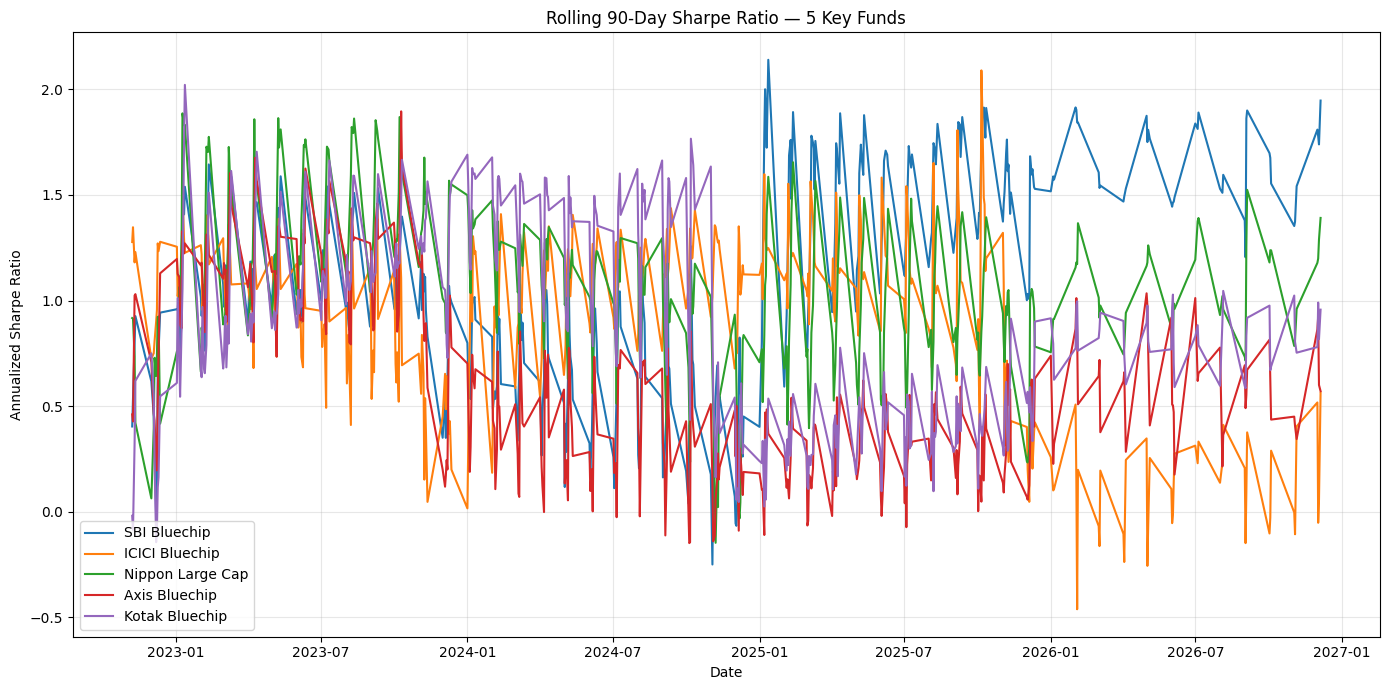

In [9]:
# Plot rolling 90-day Sharpe ratios for the 5 key funds

plt.figure(figsize=(14, 7))

for fund_name, data in rolling_sharpe.items():
    plt.plot(
        data["date"],
        data["rolling_sharpe"],
        label=fund_name
    )

plt.title("Rolling 90-Day Sharpe Ratio — 5 Key Funds")
plt.xlabel("Date")
plt.ylabel("Annualized Sharpe Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Save the rolling Sharpe chart
chart_path = "rolling_sharpe_chart.png"

plt.savefig(chart_path, dpi=300, bbox_inches="tight")
print("Chart saved:", chart_path)

Chart saved: rolling_sharpe_chart.png


<Figure size 640x480 with 0 Axes>

#Investor Cohort Analysis

In [11]:
# Load the cleaned investor transactions

transactions_df = pd.read_csv(
    "/content/drive/MyDrive/Bluestock /capstone/cleaned/investor_transactions_cleaned.csv"
)

print("Shape:", transactions_df.shape)
print("Columns:", transactions_df.columns.tolist())
display(transactions_df.head())

Shape: (32778, 13)
Columns: ['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [12]:
# Prepare transaction dates and transaction types
transactions_df["transaction_date"] = pd.to_datetime(
    transactions_df["transaction_date"],
    errors="coerce"
)

transactions_df["amount_inr"] = pd.to_numeric(
    transactions_df["amount_inr"],
    errors="coerce"
)

transactions_df = transactions_df.dropna(
    subset=["investor_id", "transaction_date", "amount_inr"]
)

# Find each investor's first transaction year
first_transaction = (
    transactions_df.groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .rename("cohort_year")
)

transactions_df = transactions_df.join(
    first_transaction,
    on="investor_id"
)

# Calculate each investor's cohort metrics
cohort_rows = []

for year, group in transactions_df.groupby("cohort_year"):
    sip_transactions = group[group["transaction_type"] == "SIP"]

    # Net invested = SIP + Lumpsum - Redemption
    total_invested = (
        group.loc[
            group["transaction_type"].isin(["SIP", "Lumpsum"]),
            "amount_inr"
        ].sum()
        - group.loc[
            group["transaction_type"] == "Redemption",
            "amount_inr"
        ].sum()
    )

    # Most-preferred fund = fund with the most transactions
    top_fund_code = group["amfi_code"].value_counts().idxmax()

    cohort_rows.append({
        "cohort_year": int(year),
        "investors": group["investor_id"].nunique(),
        "avg_sip_amount_inr": sip_transactions["amount_inr"].mean(),
        "total_invested_inr": total_invested,
        "top_fund_amfi_code": top_fund_code
    })

cohort_df = pd.DataFrame(cohort_rows).sort_values("cohort_year")

display(cohort_df)

,cohort_year,investors,avg_sip_amount_inr,total_invested_inr,top_fund_amfi_code
0,2024,4803,10996.885825,1024999421,148568
1,2025,197,13505.209581,7530027,120507


In [13]:
# Map each cohort's top fund AMFI code to its scheme name
fund_master_df = pd.read_csv(
    "/content/drive/MyDrive/Bluestock /capstone/cleaned/fund_master_cleaned.csv"
)

fund_master_df["amfi_code"] = pd.to_numeric(
    fund_master_df["amfi_code"], errors="coerce"
)

cohort_df["top_fund_amfi_code"] = pd.to_numeric(
    cohort_df["top_fund_amfi_code"], errors="coerce"
)

cohort_df = cohort_df.merge(
    fund_master_df[["amfi_code", "scheme_name"]],
    left_on="top_fund_amfi_code",
    right_on="amfi_code",
    how="left"
)

cohort_df = cohort_df.drop(columns=["amfi_code"])

display(cohort_df)

,cohort_year,investors,avg_sip_amount_inr,total_invested_inr,top_fund_amfi_code,scheme_name
0,2024,4803,10996.885825,1024999421,148568,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,197,13505.209581,7530027,120507,ICICI Pru Liquid Fund - Regular - Growth


#SIP Continuity Analysis

In [14]:
# Keep only SIP transactions
sip_df = transactions_df[
    transactions_df["transaction_type"] == "SIP"
].copy()

# Ensure dates are datetime values
sip_df["transaction_date"] = pd.to_datetime(
    sip_df["transaction_date"],
    errors="coerce"
)

sip_df = sip_df.dropna(
    subset=["investor_id", "transaction_date"]
)

# Count SIP transactions per investor
sip_counts = sip_df.groupby("investor_id").size()

# Keep investors with at least 6 SIP transactions
eligible_investors = sip_counts[sip_counts >= 6].index

eligible_sips = sip_df[
    sip_df["investor_id"].isin(eligible_investors)
].copy()

print("Investors with 6+ SIP transactions:", len(eligible_investors))
display(eligible_sips.head())

Investors with 6+ SIP transactions: 1362


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024
8,INV003670,2024-01-01,119120,SIP,10672,Punjab,Chandigarh,T30,36-45,Male,38.4,Net Banking,Verified,2024
11,INV001023,2024-01-01,118636,SIP,4865,Gujarat,Ahmedabad,T30,36-45,Male,27.1,Net Banking,Verified,2024


In [15]:
# Calculate the average gap between SIP dates for each eligible investor

eligible_sips = eligible_sips.sort_values(
    ["investor_id", "transaction_date"]
).copy()

eligible_sips["gap_days"] = (
    eligible_sips.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_continuity_df = (
    eligible_sips.groupby("investor_id")
    .agg(
        sip_transactions=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean")
    )
    .reset_index()
)

sip_continuity_df["status"] = np.where(
    sip_continuity_df["avg_gap_days"] > 35,
    "At-risk",
    "Regular"
)

print("Eligible investors:", len(sip_continuity_df))
print("At-risk investors:", (sip_continuity_df["status"] == "At-risk").sum())

display(sip_continuity_df.head(10))

Eligible investors: 1362
At-risk investors: 1332


,investor_id,sip_transactions,avg_gap_days,status
0,INV000004,6,85.400000,At-risk
1,INV000008,6,70.400000,At-risk
2,INV000010,6,64.800000,At-risk
3,INV000011,7,40.166667,At-risk
4,INV000012,8,57.000000,At-risk
5,INV000013,7,55.333333,At-risk
6,INV000014,7,75.333333,At-risk
7,INV000023,8,58.571429,At-risk
8,INV000028,6,93.600000,At-risk
9,INV000029,7,60.666667,At-risk


In [16]:
# Calculate SIP continuity rate among investors with 6+ SIP transactions

regular_count = (sip_continuity_df["status"] == "Regular").sum()
eligible_count = len(sip_continuity_df)

continuity_rate = (regular_count / eligible_count) * 100

print("Eligible investors:", eligible_count)
print("Regular investors:", regular_count)
print(f"SIP continuity rate: {continuity_rate:.2f}%")

Eligible investors: 1362
Regular investors: 30
SIP continuity rate: 2.20%


#Simple Fund Recommender

In [20]:
# Check the actual risk categories and scorecard columns

print("Risk categories:")
print(fund_master_df["risk_category"].value_counts(dropna=False))

print("\nScorecard columns:")
print(scorecard_df.columns.tolist())

display(fund_master_df[["amfi_code", "scheme_name", "risk_category"]].head())
display(scorecard_df[["amfi_code", "scheme_name", "Sharpe_Ratio"]].head())

Risk categories:
risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

Scorecard columns:
['amfi_code', 'scheme_name', 'CAGR_3Y', 'Sharpe_Ratio', 'Alpha', 'expense_ratio_pct', 'Max_Drawdown', 'Fund_Score']


,amfi_code,scheme_name,risk_category
0,119551,SBI Bluechip Fund - Regular Plan - Growth,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Low


,amfi_code,scheme_name,Sharpe_Ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448291
1,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180101
2,120843,Kotak Flexicap Fund - Regular - Growth,1.306744
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.026524


In [23]:
# Simple risk-based mutual fund recommender

# Join fund risk categories with Day 4 Sharpe ratios
recommender_df = fund_master_df[
    ["amfi_code", "scheme_name", "risk_category"]
].merge(
    scorecard_df[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code",
    how="inner"
)

# Match the user's risk appetite to the dataset's risk categories
risk_mapping = {
    "Low": ["Low"],
    "Moderate": ["Moderate", "Moderately High"],
    "High": ["High", "Very High"]
}

def recommend_funds(risk_appetite):
    risk_appetite = risk_appetite.strip().title()

    if risk_appetite not in risk_mapping:
        print("Please enter Low, Moderate, or High.")
        return

    matching_funds = recommender_df[
        recommender_df["risk_category"].isin(
            risk_mapping[risk_appetite]
        )
    ]

    recommendations = (
        matching_funds
        .dropna(subset=["Sharpe_Ratio"])
        .sort_values("Sharpe_Ratio", ascending=False)
        .head(3)
        .copy()
    )

    recommendations["Sharpe_Ratio"] = (
        recommendations["Sharpe_Ratio"].round(4)
    )

    print(f"Top 3 funds for {risk_appetite} risk appetite:")
    display(
        recommendations[
            ["scheme_name", "risk_category", "Sharpe_Ratio"]
        ].reset_index(drop=True)
    )

# Try one risk appetite
recommend_funds("Moderate")

Top 3 funds for Moderate risk appetite:


,scheme_name,risk_category,Sharpe_Ratio
0,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.4483
1,Kotak Flexicap Fund - Regular - Growth,Moderately High,1.3067
2,SBI Bluechip Fund - Regular Plan - Growth,Moderate,1.2083


In [24]:
# Ask the user to choose a risk appetite
risk_appetite = input("Enter risk appetite (Low / Moderate / High): ")

recommend_funds(risk_appetite)

Enter risk appetite (Low / Moderate / High): High
Top 3 funds for High risk appetite:


,scheme_name,risk_category,Sharpe_Ratio
0,Mirae Asset Tax Saver Fund - Regular - Growth,High,1.2349
1,ICICI Pru Midcap Fund - Regular - Growth,High,1.1801
2,DSP Midcap Fund - Regular - Growth,High,1.1321


In [27]:
fund_holdings_df = pd.read_csv(
    "/content/drive/MyDrive/Bluestock /capstone/cleaned/fund_holdings_cleaned.csv"
)

print(fund_holdings_df.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


#Sector HHI

In [28]:
# Keep only equity funds
equity_codes = fund_master_df.loc[
    fund_master_df["category"].str.contains("equity", case=False, na=False),
    "amfi_code"
].unique()

equity_holdings = fund_holdings_df[
    fund_holdings_df["amfi_code"].isin(equity_codes)
].copy()

# Convert holding weights to numbers
equity_holdings["weight_pct"] = pd.to_numeric(
    equity_holdings["weight_pct"], errors="coerce"
)

# Calculate sector weight and HHI for each fund
sector_weights = (
    equity_holdings
    .groupby(["amfi_code", "sector"], as_index=False)["weight_pct"]
    .sum()
)

sector_weights["total_weight"] = (
    sector_weights.groupby("amfi_code")["weight_pct"].transform("sum")
)

sector_weights["normalized_weight"] = (
    sector_weights["weight_pct"] / sector_weights["total_weight"]
)

hhi_df = (
    sector_weights
    .assign(sector_hhi=lambda df: df["normalized_weight"] ** 2)
    .groupby("amfi_code", as_index=False)["sector_hhi"]
    .sum()
)

print("Equity funds with HHI calculated:", len(hhi_df))
display(hhi_df.head())

Equity funds with HHI calculated: 34


,amfi_code,sector_hhi
0,100016,0.180588
1,100033,0.227647
2,101206,0.180006
3,101207,0.222771
4,102885,0.180712


In [29]:
hhi_df = hhi_df.merge(
    fund_master_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

hhi_df = hhi_df[
    ["amfi_code", "scheme_name", "sector_hhi"]
].sort_values("sector_hhi", ascending=False)

hhi_df.to_csv("sector_hhi_report.csv", index=False)

print("Saved sector_hhi_report.csv")
display(hhi_df.head())

Saved sector_hhi_report.csv


,amfi_code,scheme_name,sector_hhi
11,119092,Axis Bluechip Fund - Regular - Growth,0.296828
30,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.255094
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.253155
6,102887,UTI Flexi Cap Fund - Regular - Growth,0.251332
32,149323,DSP Midcap Fund - Regular - Growth,0.241077


#5 advanced insights

In [32]:
display(hhi_df.head(10))
display(var_cvar_df.head(10))
display(cohort_df)

,amfi_code,scheme_name,sector_hhi
11,119092,Axis Bluechip Fund - Regular - Growth,0.296828
30,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.255094
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.253155
6,102887,UTI Flexi Cap Fund - Regular - Growth,0.251332
32,149323,DSP Midcap Fund - Regular - Growth,0.241077
21,120505,ICICI Pru Midcap Fund - Regular - Growth,0.238600
10,118635,Nippon India ETF Nifty 50 BeES,0.237544
18,119599,SBI Small Cap Fund - Direct Plan - Growth,0.232361
22,120506,ICICI Pru Value Discovery Fund - Regular - Growth,0.231372
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.227647


,amfi_code,VaR_95,CVaR_95
0,100016,-0.064206,-0.105590
1,100025,-0.020707,-0.042778
2,100033,-0.069870,-0.174555
3,101206,-0.074686,-0.151855
4,101207,-0.089537,-0.161950
5,101208,-0.000670,-0.046342
6,102885,-0.039924,-0.122994
7,102886,-0.069130,-0.119150
8,102887,-0.059983,-0.157461
9,118632,-0.062062,-0.166424


,cohort_year,investors,avg_sip_amount_inr,total_invested_inr,top_fund_amfi_code,scheme_name
0,2024,4803,10996.885825,1024999421,148568,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,197,13505.209581,7530027,120507,ICICI Pru Liquid Fund - Regular - Growth


In [33]:
print("Lowest HHI:")
display(hhi_df.nsmallest(1, "sector_hhi"))

print("Highest HHI:")
display(hhi_df.nlargest(1, "sector_hhi"))

Lowest HHI:


,amfi_code,scheme_name,sector_hhi
5,102886,UTI Mid Cap Fund - Regular - Growth,0.12407


Highest HHI:


,amfi_code,scheme_name,sector_hhi
11,119092,Axis Bluechip Fund - Regular - Growth,0.296828


###     Five Advanced Insights

1. **Sector concentration varies across equity funds:** Axis Bluechip Fund has the highest sector HHI (0.296828), while UTI Mid Cap Fund has the lowest (0.124070). This indicates different levels of sector concentration in their portfolios.

2. **The 2024 investor cohort was much larger:** It included 4,803 investors, compared with 197 investors in the 2025 cohort.

3. **The 2025 cohort had a higher average SIP amount:** Its average SIP transaction amount was ₹13,505.21, compared with ₹10,996.89 for the 2024 cohort.

4. **SIP continuity needs attention in the analyzed data:** Of 1,362 investors with at least six SIP transactions, 1,332 were classified as at-risk because their average gap between SIP dates exceeded 35 days. The continuity rate was 2.20%, based on this project's definition.

5. **Risk-based recommendations differ by risk appetite:** The recommender returned the top three funds by Sharpe ratio for Low, Moderate, and High risk categories. This demonstrates how risk category and Sharpe ratio can be used together to create a simple shortlist.

In [34]:
%%writefile recommender.py

import pandas as pd

# Load the fund master and Day 4 scorecard CSV files.
fund_master_df = pd.read_csv(
    "/content/drive/MyDrive/Bluestock /capstone/cleaned/fund_master_cleaned.csv"
)

scorecard_df = pd.read_csv(
    "/content/drive/MyDrive/Bluestock /capstone/cleaned/fund_scorecard.csv"
)

# Keep fund names, risk categories, and Sharpe ratios.
recommender_df = fund_master_df[
    ["amfi_code", "scheme_name", "risk_category"]
].merge(
    scorecard_df[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code",
    how="inner"
)

risk_mapping = {
    "Low": ["Low"],
    "Moderate": ["Moderate", "Moderately High"],
    "High": ["High", "Very High"]
}

def recommend_funds(risk_appetite):
    risk_appetite = risk_appetite.strip().title()

    if risk_appetite not in risk_mapping:
        print("Please enter Low, Moderate, or High.")
        return

    matching_funds = recommender_df[
        recommender_df["risk_category"].isin(
            risk_mapping[risk_appetite]
        )
    ]

    recommendations = (
        matching_funds
        .dropna(subset=["Sharpe_Ratio"])
        .sort_values("Sharpe_Ratio", ascending=False)
        .head(3)
    )

    print(f"Top 3 funds for {risk_appetite} risk appetite:")

    display(
        recommendations[
            ["scheme_name", "risk_category", "Sharpe_Ratio"]
        ].reset_index(drop=True)
    )

if __name__ == "__main__":
    risk_appetite = input("Enter risk appetite (Low / Moderate / High): ")
    recommend_funds(risk_appetite)

Writing recommender.py
